# <span style="color:red"> **LSN - Esercitazione 07**
### <span style="color:green"> 24.04.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
Il codice di simulazione non è aggiornato con cose implementate nell'esercitazione 6.

#### Esercizio 07.1
- produrre valore di energia potenziale e pressione con tail aggiunte
- nelle formule delle tail ho messo $\epsilon = 1$: è corretto?

#### Esercizio 07.2
- produrre valori di U/N e non di U: devo dunque dividere tutto per N=108?
- incertezza statistica dell'autocorrelazione. devo calcolare valori e incertezze con data blocking?

#### Esercizio 07.3

#### Esercizio 07.4

## <span style="color:blue">**Esercizio 07.1**

## <span style="color:blue">**Esercizio 07.2**

Perché il sistema si equilibrasse, ho scartato i primi 5.000 steps (cioè ho fatto una simulazione di equilibrazione con 5.000 steps, e poi sono ripartita dal punto finale di questa simulazione come punto di partenza per i dati che effettivamente prendo).
Per simulazione MC, osservo che con delta = 0.1 ottengo accettazione del 50%, come richiesto.

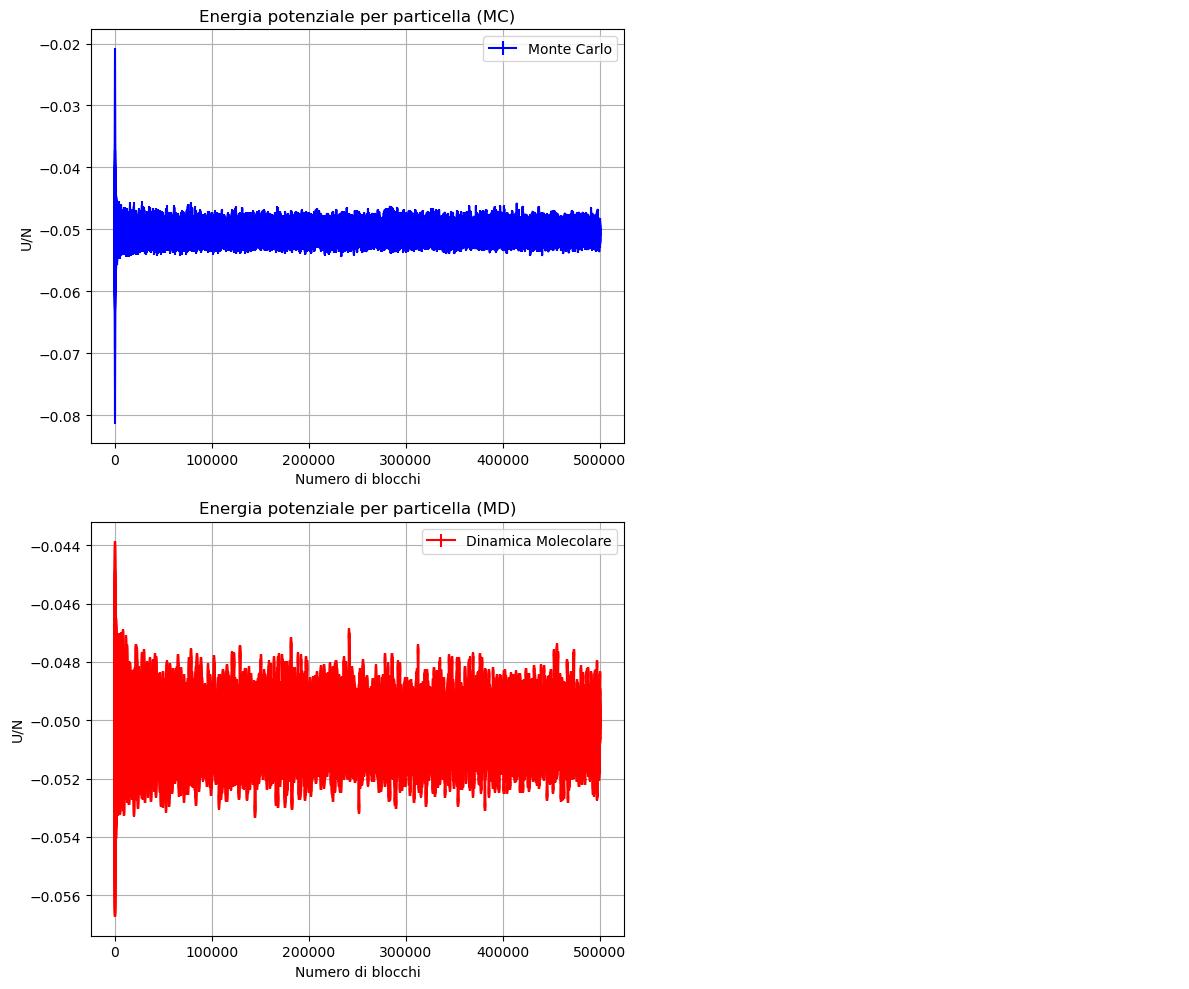

In [39]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

N = 108  # Numero totale di particelle

# Carico i dati dal file
data_U_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
# data_p_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/pressure.dat")
data_U_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")
# data_p_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/pressure.dat")

# Estraggo le colonne di dati
x = data_U_MC[:, 0]         # Prima colonna: numero di blocchi
y_U_MC = data_U_MC[:, 1]    # Seconda colonna: valori istantanei
err_U_MC = data_U_MC[:, 3]  # Quarta colonna: errore

# y_p_MC = data_p_MC[:, 1]
# err_p_MC = data_p_MC[:, 3]

y_U_MD = data_U_MD[:, 1]
err_U_MD = data_U_MD[:, 3]

# y_p_MD = data_p_MD[:, 1]
# err_p_MD = data_p_MD[:, 3]

# Creazione di una figura con 2 righe e 2 colonne
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# U/N Monte Carlo
axes[0, 0].errorbar(x, y_U_MC/N, yerr=err_U_MC, color='b', label='Monte Carlo')
axes[0, 0].set_xlabel("Numero di blocchi")
axes[0, 0].set_ylabel("U/N")
axes[0, 0].set_title("Energia potenziale per particella (MC)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Pressione Monte Carlo
# axes[0, 1].errorbar(x, y_p_MC, yerr=err_p_MC, color='g', label='Monte Carlo')
# axes[0, 1].set_xlabel("Numero di blocchi")
# axes[0, 1].set_ylabel("p")
# axes[0, 1].set_title("Pressione (MC)")
# axes[0, 1].legend()
# axes[0, 1].grid(True)

# U/N Dinamica Molecolare
axes[1, 0].errorbar(x, y_U_MD/N, yerr=err_U_MD, color='r', label='Dinamica Molecolare')
axes[1, 0].set_xlabel("Numero di blocchi")
axes[1, 0].set_ylabel("U/N")
axes[1, 0].set_title("Energia potenziale per particella (MD)")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Pressione Dinamica Molecolare
# axes[1, 1].errorbar(x, y_p_MD, yerr=err_p_MD, color='orange', label='Molecolare')
# axes[1, 1].set_xlabel("Numero di blocchi")
# axes[1, 1].set_ylabel("p")
# axes[1, 1].set_title("Pressione (MD)")
# axes[1, 1].legend()
# axes[1, 1].grid(True)

# Rimuovo il subplot vuoto se non uso [0,1] e [1,1]
axes[0, 1].axis('off')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data_MC = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
data_MD = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data_MC[:, 0]   # Prima colonna: contiene il numero di blocchi
U_MC = data_MC[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
U_MD = data_MD[:, 1]
autocorrelation_MC = [] # Array per contenere il valore della autocorrelazione
autocorrelation_MD = []
t_calcolati = []

for i in range(1,300):
    a_MC = 0.0
    a_MD = 0.0
    b_MC = 0.0
    b_MD = 0.0
    c_MC = 0.0
    c_MD = 0.0
    d_MC = 0.0
    d_MD = 0.0
    e_MC = 0.0
    e_MD = 0.0
    for j in range( t_max - i ):
        a_MC += U_MC[j] * U_MC[j+i]
        a_MD += U_MD[j] * U_MD[j+i]
        b_MC += U_MC[j]
        b_MD += U_MD[j]
        c_MC += U_MC[j+i]
        c_MD += U_MD[j+i]
    for k in range ( t_max):
        d_MC += U_MC[k] * U_MC[k]
        d_MD += U_MD[k] * U_MD[k]
        e_MC += U_MC[k]
        e_MD += U_MD[k]
    autocorrelation_MC.append(( (1. / (t_max - i) * a_MC ) - 1./(t_max - i) * b_MC * 1./(t_max - i) * c_MC ) / ( (1./ t_max) * d_MC - ( (1./ t_max) * e_MC )**2 ))
    autocorrelation_MD.append(( (1. / (t_max - i) * a_MD ) - 1./(t_max - i) * b_MD * 1./(t_max - i) * c_MD ) / ( (1./ t_max) * d_MD - ( (1./ t_max) * e_MD )**2 ))
    t_calcolati.append(i)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

# Primo grafico
axes[0].plot(t_calcolati, autocorrelation_MC,  color='b', label='Monte Carlo')
axes[0].set_title("Funzioni di autocorrelazione di U/N")
axes[0].legend()
axes[0].grid(True)

# Secondo grafico
axes[1].plot(t_calcolati, autocorrelation_MD,  color='r', label='Dinamica Molecolare')
axes[1].set_title("Funzioni di autocorrelazione di U/N")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


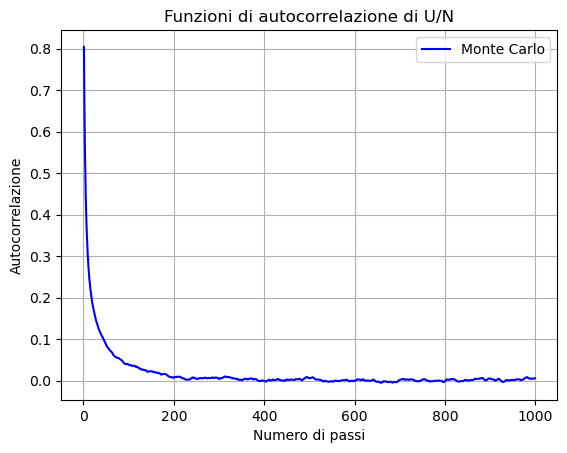

In [51]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data[:, 0]   # Prima colonna: contiene il numero di blocchi
U = data[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
autocorrelation = [] # Array per contenere il valore della autocorrelazione
t_calcolati = []

for i in range(1,1000):
    a = 0.0
    b = 0.0
    c = 0.0
    d = 0.0
    e = 0.0
    for j in range( t_max - i ):
        a += U[j] * U[j+i]
        b += U[j]
        c += U[j+i]
    for k in range ( t_max):
        d += U[k] * U[k]
        e += U[k]
    autocorrelation.append(( (1. / (t_max - i) * a ) - 1./(t_max - i) * b * 1./(t_max - i) * c ) / ( (1./ t_max) * d - ( (1./ t_max) * e )**2 ))
    t_calcolati.append(i)

plt.errorbar(t_calcolati, autocorrelation,  color='b', label='Monte Carlo')
plt.title("Funzioni di autocorrelazione di U/N")
plt.xlabel("Numero di passi")
plt.ylabel("Autocorrelazione")
plt.legend()
plt.grid(True)
plt.show()


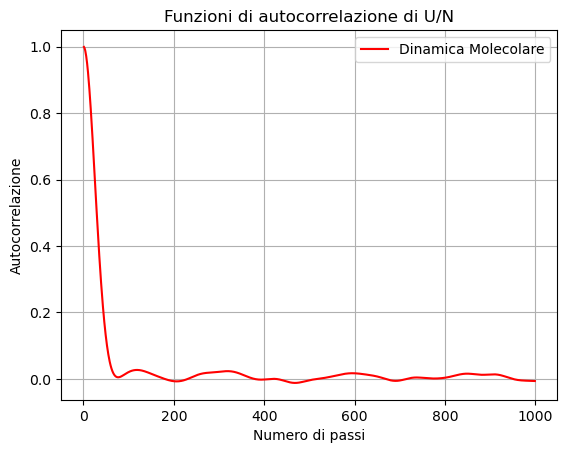

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

t_max = 500_000

# Carico i dati dal file
data = np.loadtxt("simulazioni-eseguite/07.2/dinamica-molecolare-equilibrata/potential_energy.dat")

# importo in un array il numero di step che faccio e in un array il valore dell'energia potenziale a ogni valore di step

t = data[:, 0]   # Prima colonna: contiene il numero di blocchi
U = data[:, 1]   # Seconda colonna: contiene il valore istantaneo di energia potenziale
autocorrelation = [] # Array per contenere il valore della autocorrelazione
t_calcolati = []

for i in range(1,1000):
    a = 0.0
    b = 0.0
    c = 0.0
    d = 0.0
    e = 0.0
    for j in range( t_max - i ):
        a += U[j] * U[j+i]
        b += U[j]
        c += U[j+i]
    for k in range ( t_max):
        d += U[k] * U[k]
        e += U[k]
    autocorrelation.append(( (1. / (t_max - i) * a ) - 1./(t_max - i) * b * 1./(t_max - i) * c ) / ( (1./ t_max) * d - ( (1./ t_max) * e )**2 ))
    t_calcolati.append(i)

plt.errorbar(t_calcolati, autocorrelation,  color='r', label='Dinamica Molecolare')
plt.title("Funzioni di autocorrelazione di U/N")
plt.xlabel("Numero di passi")
plt.ylabel("Autocorrelazione")
plt.legend()
plt.grid(True)
plt.show()


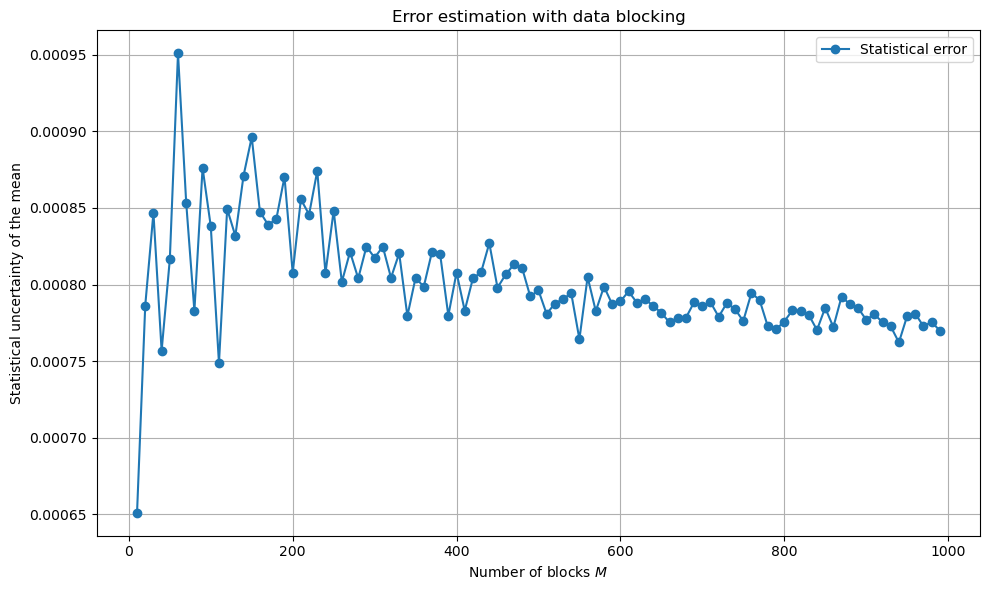

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Load your data: assume the 2nd column is the observable (e.g., U)
data = np.loadtxt("simulazioni-eseguite/07.2/monte-carlo-equilibrata/potential_energy.dat")
observable = data[:, 1]  # Adjust if needed
N = len(observable)

# Define block numbers to test
M_values = np.arange(10, 1000, 10)  # number of blocks
errors = []

for M in M_values:
    L = N // M  # block length
    if L == 0:
        continue  # skip if too many blocks

    block_avgs = np.array([np.mean(observable[i*L:(i+1)*L]) for i in range(M)])
    mean = np.mean(block_avgs)
    std_err = np.sqrt(np.var(block_avgs, ddof=1) / M)
    errors.append(std_err)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_values[:len(errors)], errors, marker='o', linestyle='-', label='Statistical error')
plt.xlabel("Number of blocks $M$")
plt.ylabel("Statistical uncertainty of the mean")
plt.title("Error estimation with data blocking")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## <span style="color:blue">**Esercizio 07.3**

## <span style="color:blue">**Esercizio 07.4**